<div class="alert alert-success">

## **Time Series Forecasting: Mobile Sales Analysis**

### **Overview**
This notebook demonstrates time series analysis and forecasting techniques using mobile sales data. We'll explore data preprocessing, decomposition, and basic forecasting methods.

### **Objectives**
- Load and explore time series data
- Perform data preprocessing and cleaning
- Conduct time series decomposition
- Analyze trends and seasonality patterns
- Prepare data for forecasting models

### **Dataset**
- **Source**: Mobile sales data (2001-2019)
- **Frequency**: Monthly
- **Duration**: 18 years and 1 month (217 observations)
- **Variables**: Date and Sales

In [6]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from datetime import datetime
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

In [7]:
# Configure plotting parameters
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 12
sns.set_palette("husl")

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")


Libraries imported successfully!
Pandas version: 2.3.2
NumPy version: 2.3.2
Matplotlib version: 3.10.5


In [10]:
# Load the mobile sales dataset
try:
    mobile_sales = pd.read_excel('data/mobilesales.xlsx')
    print(f"Dataset shape: {mobile_sales.shape}")
    print(f"Columns: {list(mobile_sales.columns)}")
except FileNotFoundError:
    print("Error: File 'data/mobilesales.xlsx' not found!")
except Exception as e:
    print(f"Error loading dataset: {str(e)}")


mobile_sales.head()

Dataset shape: (217, 2)
Columns: ['DATE', 'Sales']


,DATE,Sales
0,2001-01-01,6519.0
1,2001-02-01,6654.0
2,2001-03-01,7332.0
3,2001-04-01,7332.0
4,2001-05-01,8240.0


In [17]:
# Examine data types and basic information
print(f"Data types:\n{mobile_sales.dtypes}")
print(f"\nMemory usage:\n{mobile_sales.memory_usage(deep=True)}")

Data types:
DATE     datetime64[ns]
Sales           float64
dtype: object

Memory usage:
Index     132
DATE     1736
Sales    1736
dtype: int64


In [19]:
print(f"\nDataset info:")
mobile_sales.info()


Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217 entries, 0 to 216
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   DATE    217 non-null    datetime64[ns]
 1   Sales   198 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 3.5 KB


In [20]:
# Statistical summary of the Sales column
print("📈 Sales Statistics:")
sales_stats = mobile_sales.Sales.describe()
print(sales_stats)

📈 Sales Statistics:
count      198.000000
mean     10842.757576
std       2605.006293
min        108.000000
25%       8856.000000
50%      10745.000000
75%      12399.750000
max      23740.000000
Name: Sales, dtype: float64


* We looked at **198 sales records**.
* On average, sales are around **10,843**.
* Usually, sales move up or down by about **2,605** from the average.
* The **lowest sale** was **108**, and the **highest** was **23,740**.
* Half of the sales are **below 10,745** and half are **above** (that’s the middle point).
* 25% of sales are **below 8,856**, and 75% are **below 12,400**.

In short: **Most sales fall between 8,800 and 12,400, with a few very small and very large sales pulling the range wider.**

In [22]:
print(f"\nMissing values: {mobile_sales.Sales.isnull().sum()}")
print(f"Zero values: {(mobile_sales.Sales == 0).sum()}")
print(f"Negative values: {(mobile_sales.Sales < 0).sum()}")


Missing values: 19
Zero values: 0
Negative values: 0


In [23]:
# Date range analysis
print("📅 Date Range Analysis:")
print(f"Date column type: {mobile_sales.DATE.dtype}")
print(f"Date range: {mobile_sales.DATE.min()} to {mobile_sales.DATE.max()}")
print(f"Total observations: {len(mobile_sales)}")

📅 Date Range Analysis:
Date column type: datetime64[ns]
Date range: 2001-01-01 00:00:00 to 2019-01-01 00:00:00
Total observations: 217


In [25]:
# Calculate time span
date_range = mobile_sales.DATE.max() - mobile_sales.DATE.min()
print(f"Time span: {date_range.days} days ({date_range.days/365.25:.1f} years)")

Time span: 6574 days (18.0 years)


In [26]:
# Check for date consistency
print(f"\nDate consistency check:")
print(f"Expected monthly frequency: {len(mobile_sales)} months")
print(f"Missing dates: {mobile_sales.DATE.isnull().sum()}")


Date consistency check:
Expected monthly frequency: 217 months
Missing dates: 0


In [ ]:
## 2. Data Preprocessing

In [27]:
mobile_sales.columns

Index(['DATE', 'Sales'], dtype='object')

In [ ]:
# Set DATE as index for time series analysis

print("Setting up time series index...")
if not isinstance(mobile_sales.index, pd.DatetimeIndex):
	mobile_sales.set_index('DATE', inplace=True)
	
	# Ensure index is datetime type
	mobile_sales.index = pd.to_datetime(mobile_sales.index)

print(f"Index type: {type(mobile_sales.index)}")

freq = pd.infer_freq(mobile_sales.index)
print(f"Index frequency: {freq if freq is not None else 'Not set'}")
mobile_sales.head()

Setting up time series index...
Index type: <class 'pandas.core.indexes.datetimes.DatetimeIndex'>
Index frequency: MS


,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


📊 Original Time Series Plot:


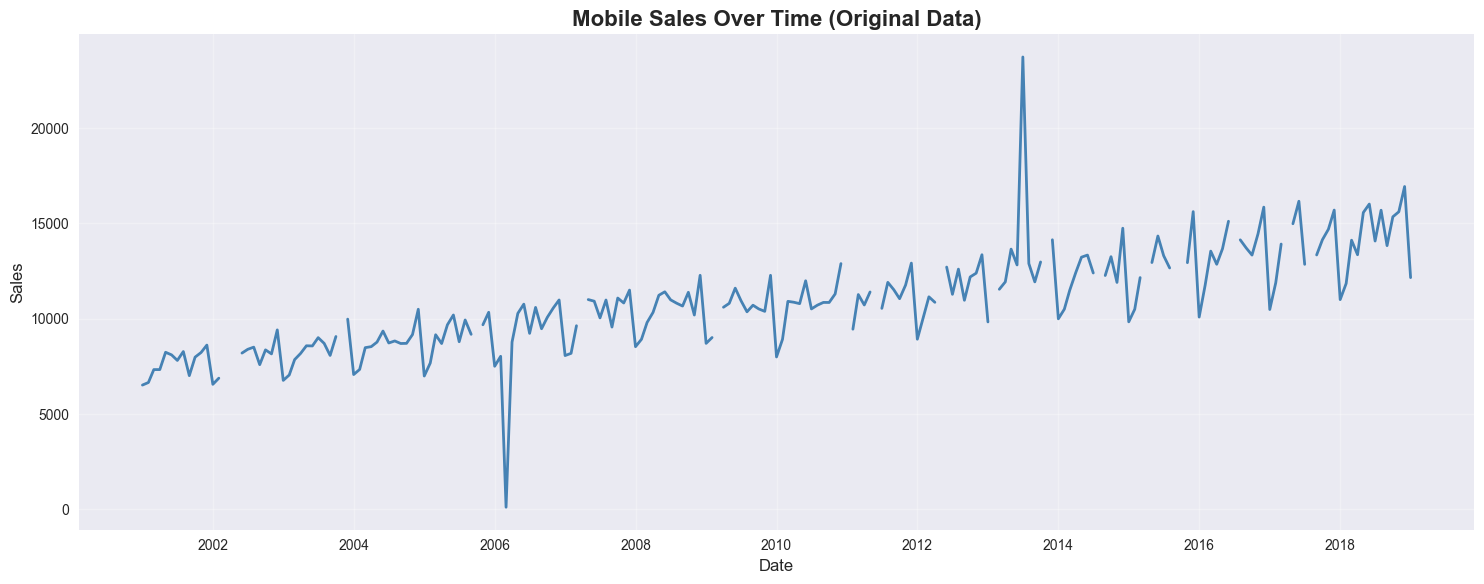


📈 Basic Statistics:
Mean sales: 10842.76
Median sales: 10745.00
Standard deviation: 2605.01
Min sales: 108.00
Max sales: 23740.00


In [ ]:
# Visualize the original time series
print("📊 Original Time Series Plot:")
plt.figure(figsize=(15, 6))
plt.plot(mobile_sales.index, mobile_sales.Sales, linewidth=2, color='steelblue')
plt.title('Mobile Sales Over Time (Original Data)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Basic statistics
print(f"\n📈 Basic Statistics:")
print(f"Mean sales: {mobile_sales.Sales.mean():.2f}")
print(f"Median sales: {mobile_sales.Sales.median():.2f}")
print(f"Standard deviation: {mobile_sales.Sales.std():.2f}")
print(f"Min sales: {mobile_sales.Sales.min():.2f}")
print(f"Max sales: {mobile_sales.Sales.max():.2f}")

In [36]:
# mobile_sales.set_index('DATE', inplace=True)

In [37]:
mobile_sales.head()

,Sales
DATE,
2001-01-01,6519.0
2001-02-01,6654.0
2001-03-01,7332.0
2001-04-01,7332.0
2001-05-01,8240.0


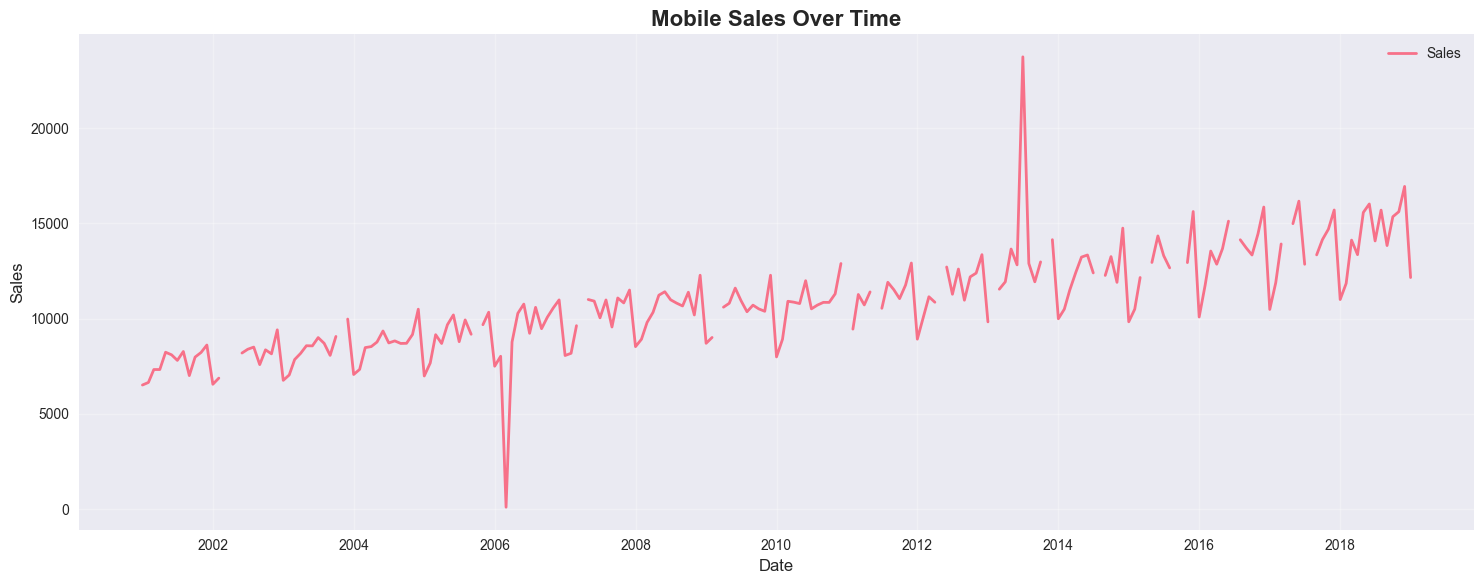

In [40]:
plt.figure(figsize=(15, 6))
plt.plot(mobile_sales.index, mobile_sales.Sales, label='Sales',  linewidth=2)
plt.title('Mobile Sales Over Time', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

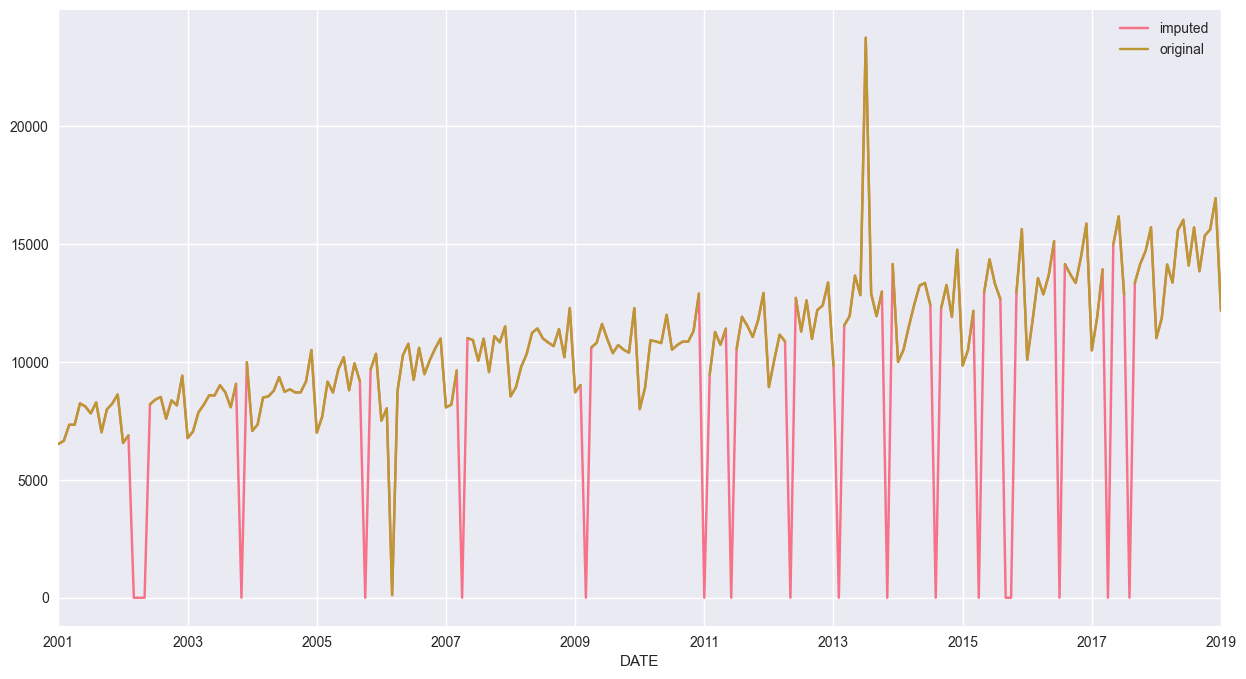

In [41]:
mobile_sales.Sales.fillna(0).plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()

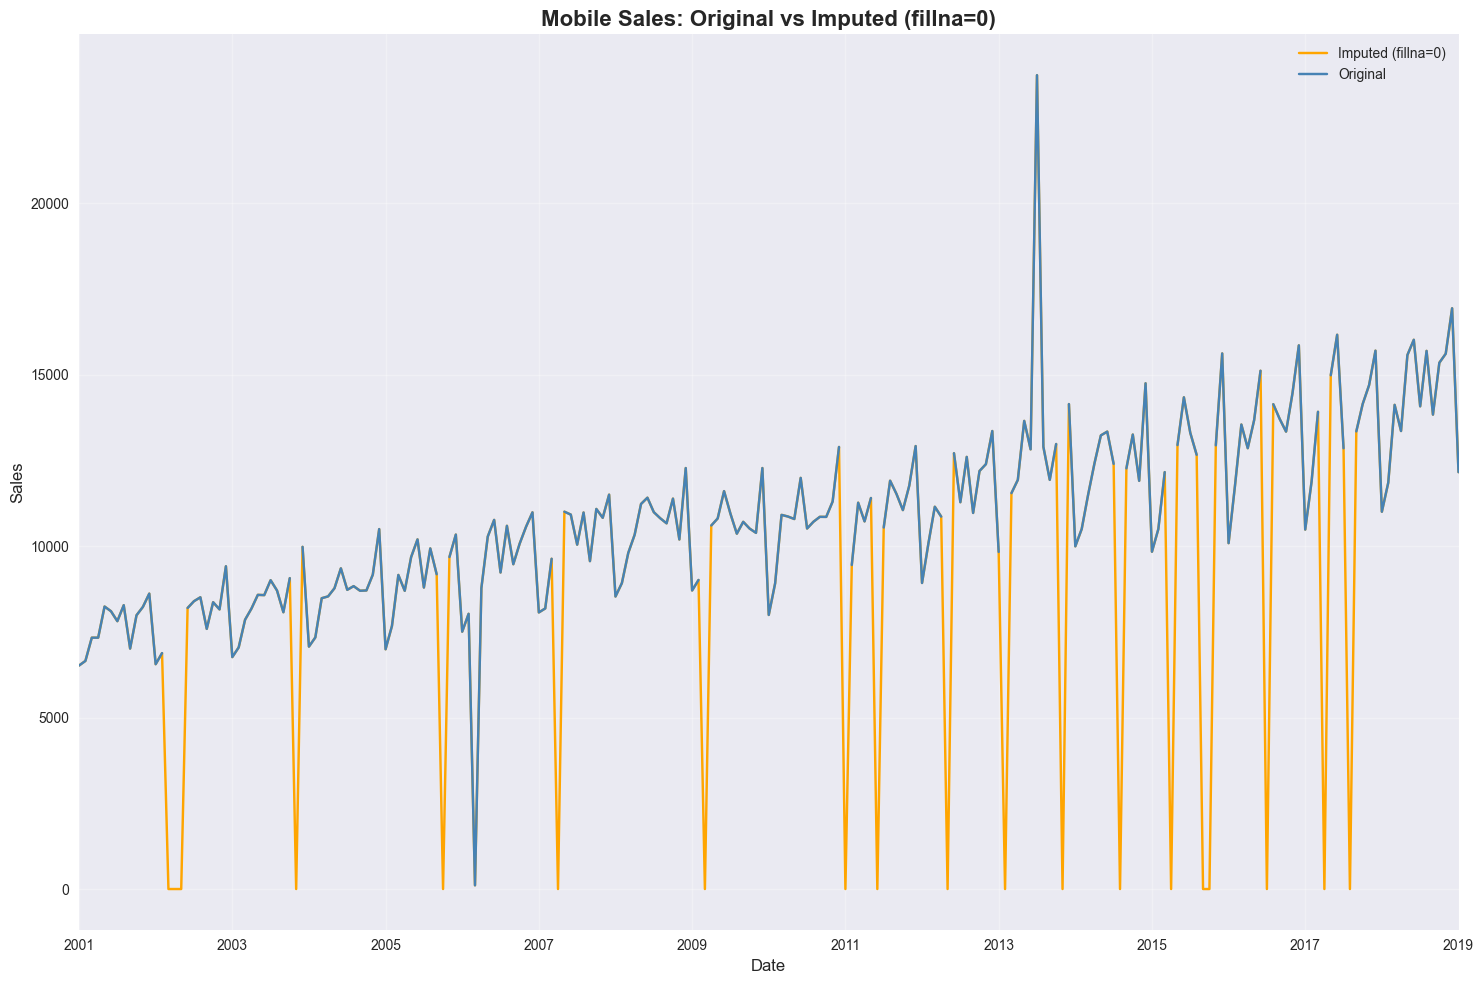

In [48]:
plt.figure(figsize=(15, 10))
mobile_sales.Sales.fillna(0).plot(label='Imputed (fillna=0)', color='orange')
mobile_sales.Sales.plot(label='Original', color='steelblue')
plt.title('Mobile Sales: Original vs Imputed (fillna=0)', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div class="alert alert-success">

### **What is Imputation?**

**Imputation** is the process of replacing missing or null values in a dataset with substituted values. In time series analysis, common imputation methods include filling with zeros, forward/backward filling, mean/median substitution, or interpolation. The choice of imputation method can significantly affect analysis results and should be selected based on the data context and analysis goals.


- `mobile_sales.Sales.fillna(0).plot(label='Imputed (fillna=0)', color='orange')`
  - **Imputes missing values** in the `Sales` column by replacing them with 0.
  - **Plots the imputed series** on the current axes.
  - **Label**: "Imputed (fillna=0)" for the legend.


**Considerations**

- If there are many NaNs, filling with 0 might distort trends; consider alternative imputations (e.g., forward fill, mean) depending on your analysis goals.
- If `mobile_sales` has a DatetimeIndex, the x-axis will reflect dates; otherwise, it will use the DataFrame's index values.



### Linear interpolation

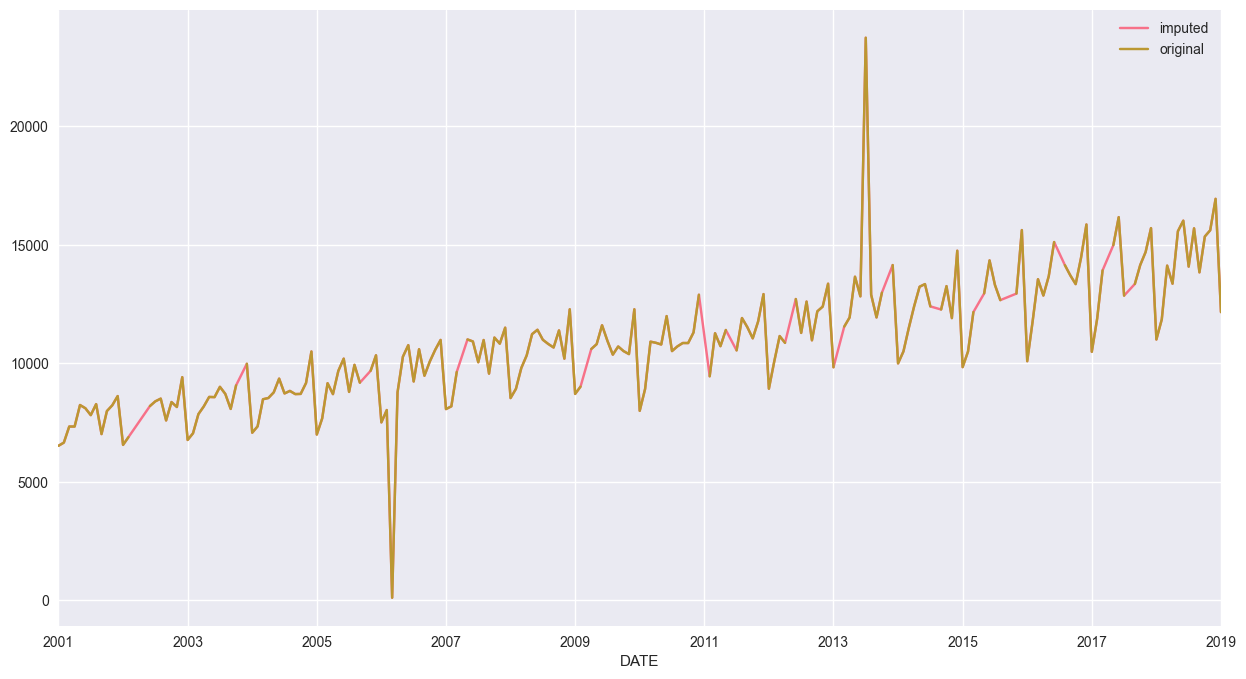

In [49]:
mobile_sales.Sales.interpolate(method='linear').plot(label='imputed')
mobile_sales.Sales.plot(label='original')
plt.legend()


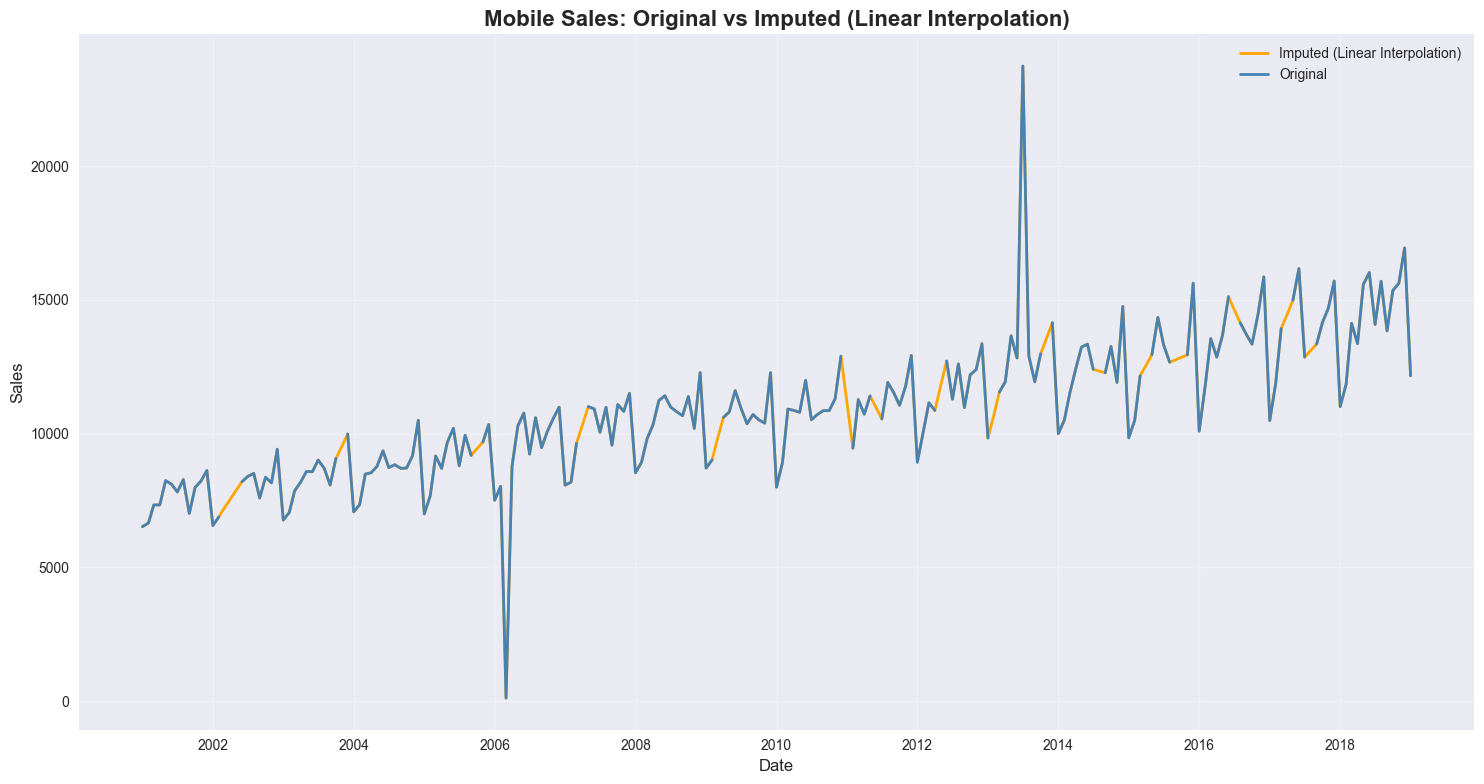

In [55]:
plt.plot(mobile_sales.index, mobile_sales.Sales.interpolate(method='linear'), 
         label='Imputed (Linear Interpolation)', 
         color='orange', 
         linewidth=2)

plt.plot(mobile_sales.index, mobile_sales.Sales, 
         label='Original', 
         color='steelblue',
        linewidth=2)

plt.title('Mobile Sales: Original vs Imputed (Linear Interpolation)', 
          fontsize=16, 
          fontweight='bold')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Sales', fontsize=12)

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [58]:
mobile_sales['Sales'] = mobile_sales['Sales'].interpolate(method='linear')
# mobile_sales.Sales = mobile_sales.Sales.interpolate(method='linear')

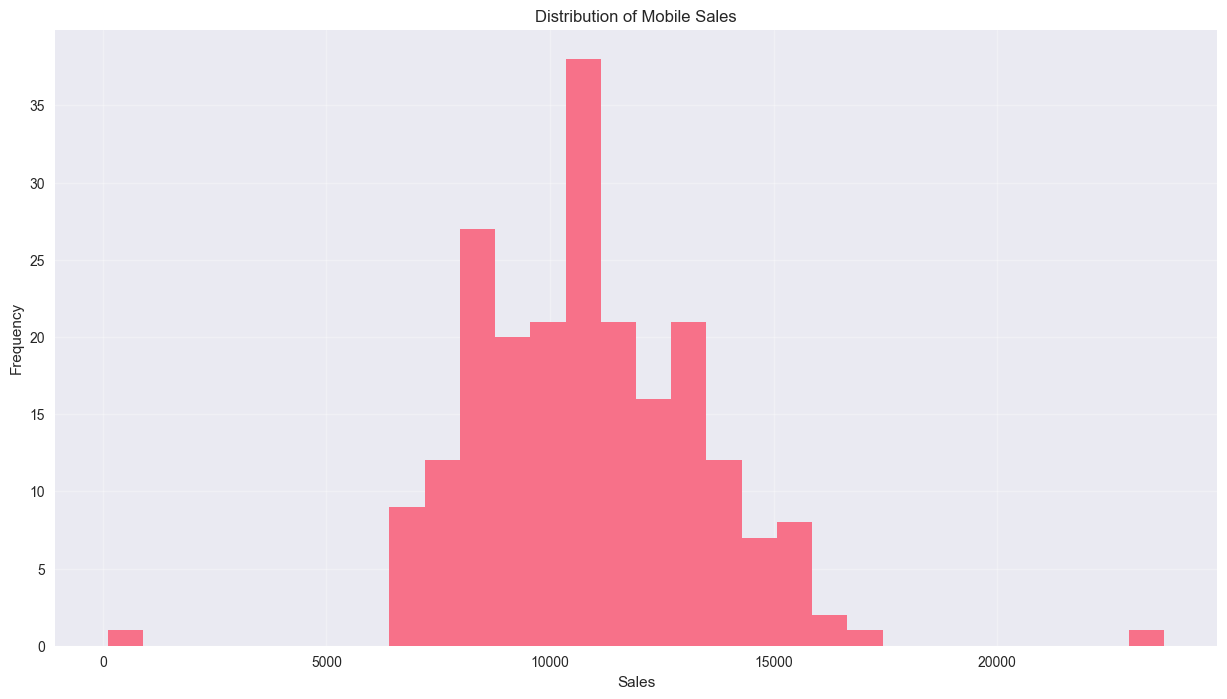

In [61]:
mobile_sales.Sales.hist(bins=30)
plt.title('Distribution of Mobile Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
mobile_sales['Sales'].quantile(0.995)

np.float64(16879.15999999999)

In [64]:
mobile_sales['Sales'].quantile(0.005)

np.float64(6522.12)

In [66]:
mobile_sales.Sales = mobile_sales.Sales.clip(upper=mobile_sales.Sales.quantile(0.99), lower=mobile_sales.Sales.quantile(0.01))

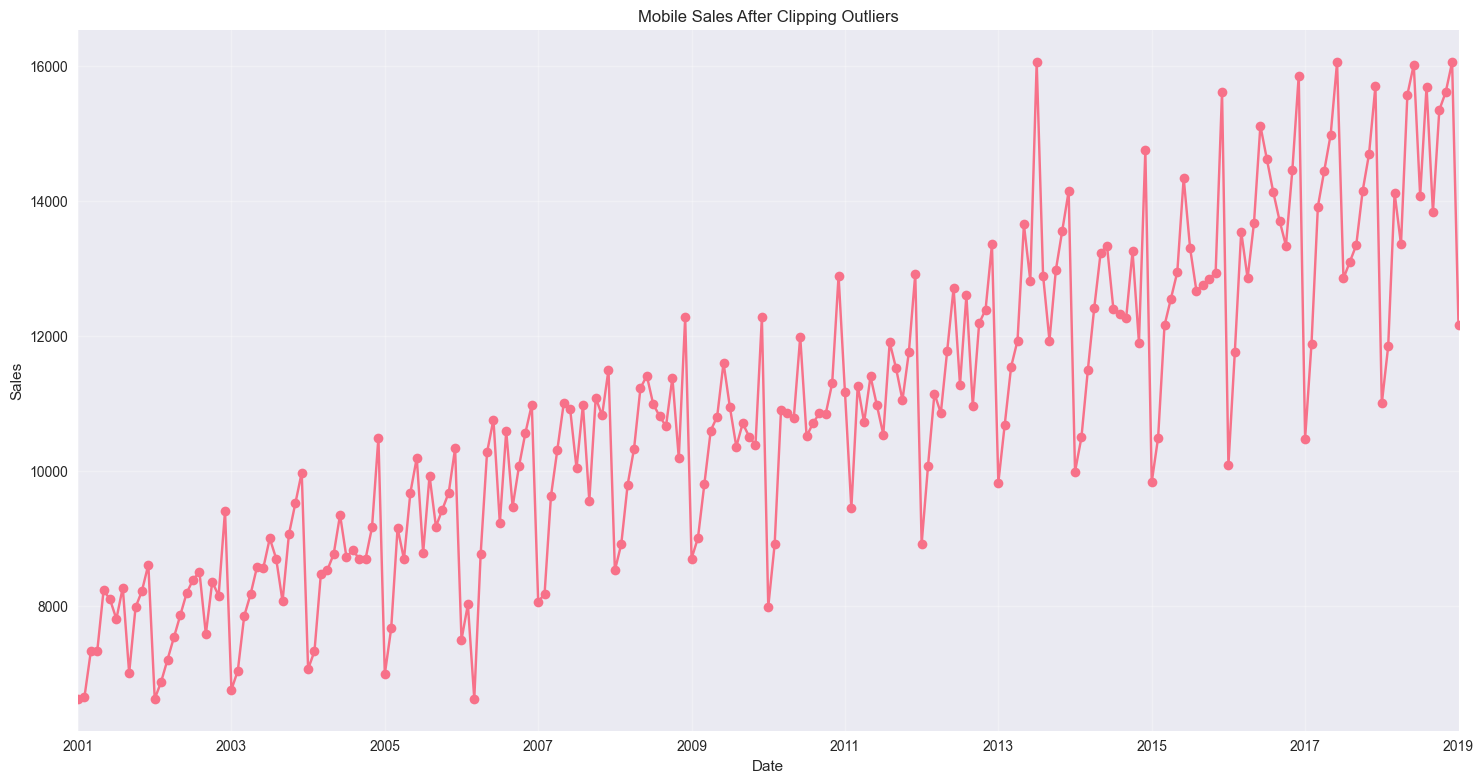

In [72]:
# Clip outliers in the Sales column to the 1st and 99th percentiles (modern pandas style)
mobile_sales['Sales'] = mobile_sales['Sales'].clip(lower=mobile_sales['Sales'].quantile(0.01),
                                                   upper=mobile_sales['Sales'].quantile(0.99))
mobile_sales['Sales'].plot(style='-o')
plt.title('Mobile Sales After Clipping Outliers')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

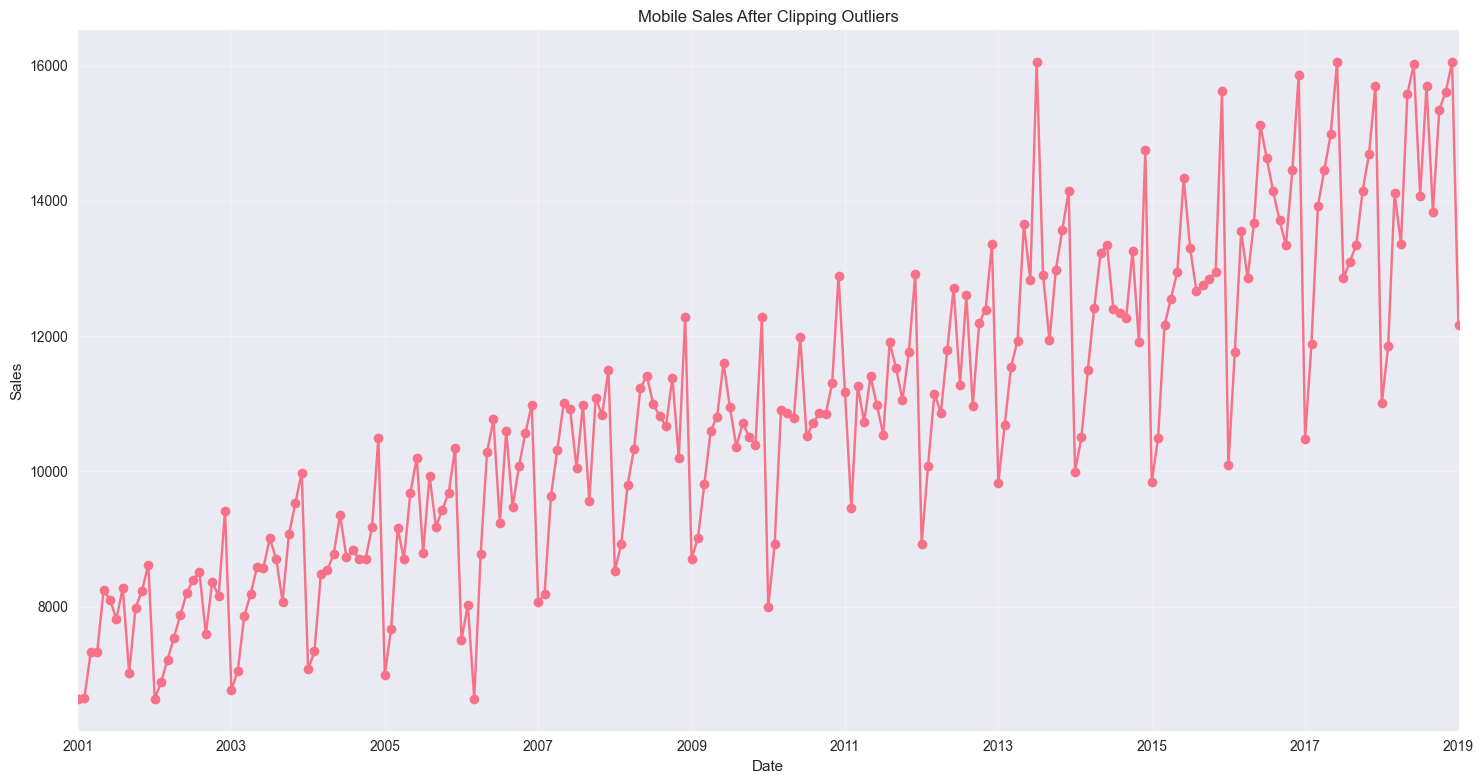

In [74]:
# Load the data and set the index
# mobile_sales = pd.read_excel('data/mobilesales.xlsx')
# mobile_sales.set_index('DATE', inplace=True)

# Interpolate missing values in Sales column using linear method
mobile_sales['Sales'] = mobile_sales['Sales'].interpolate(method='linear')

# Clip outliers in Sales to the 1st and 99th percentiles
mobile_sales['Sales'] = mobile_sales['Sales'].clip(lower=mobile_sales['Sales'].quantile(0.01),
                                                   upper=mobile_sales['Sales'].quantile(0.99))

# Plot the Sales after clipping
mobile_sales['Sales'].plot(style='-o')
plt.title('Mobile Sales After Clipping Outliers')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

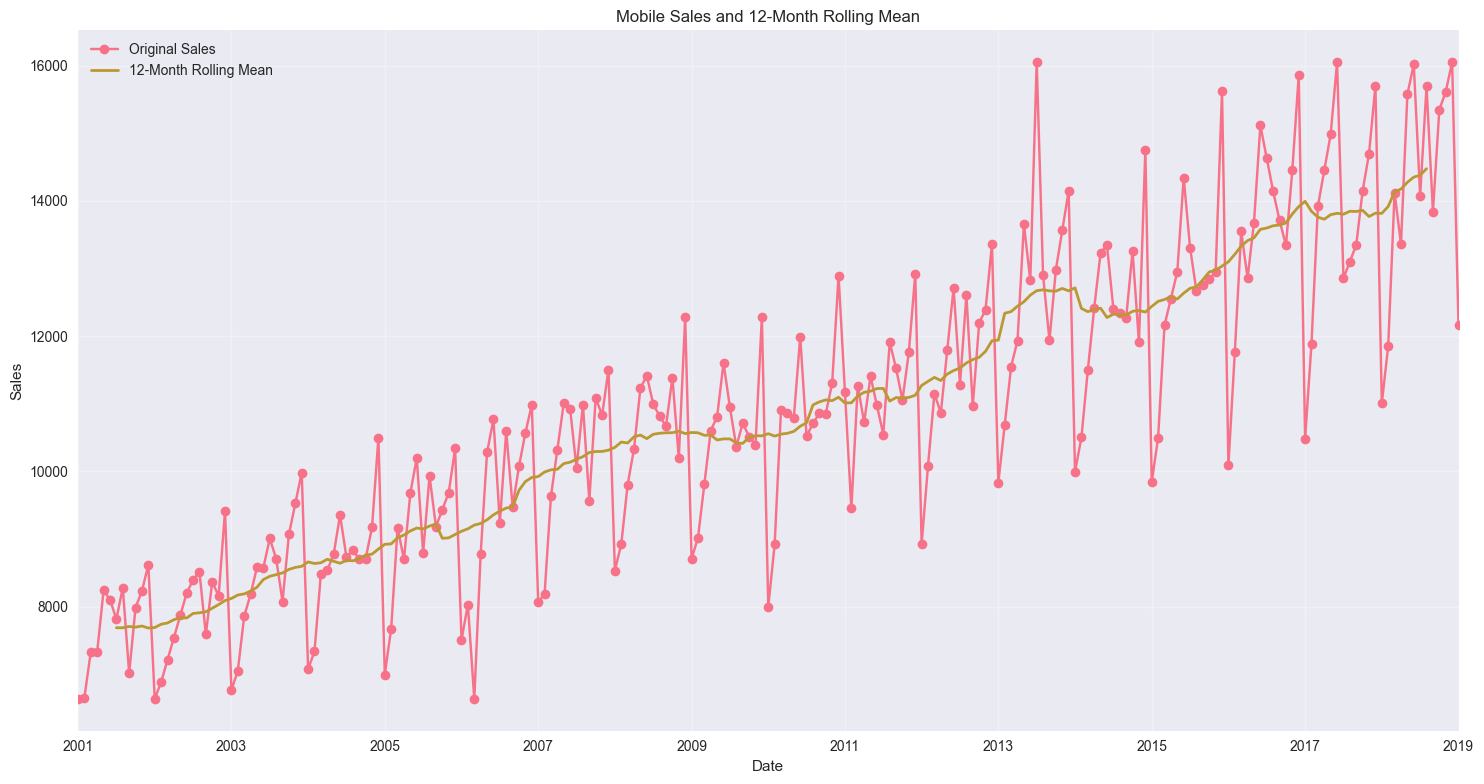

In [75]:
# Plot original Sales and 12-month centered rolling mean
ax = mobile_sales['Sales'].plot(style='-o', label='Original Sales')
mobile_sales['Sales'].rolling(window=12, center=True).mean().plot(ax=ax, label='12-Month Rolling Mean', linewidth=2)
plt.title('Mobile Sales and 12-Month Rolling Mean')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

“This chart shows how sales are moving month to month, and the rolling mean gives us a clear picture of the **long-term trend** without short-term noise.”


### **Decomposition**

In [76]:
import statsmodels.api as sm
model = sm.tsa.seasonal_decompose(mobile_sales.Sales, model='additive')

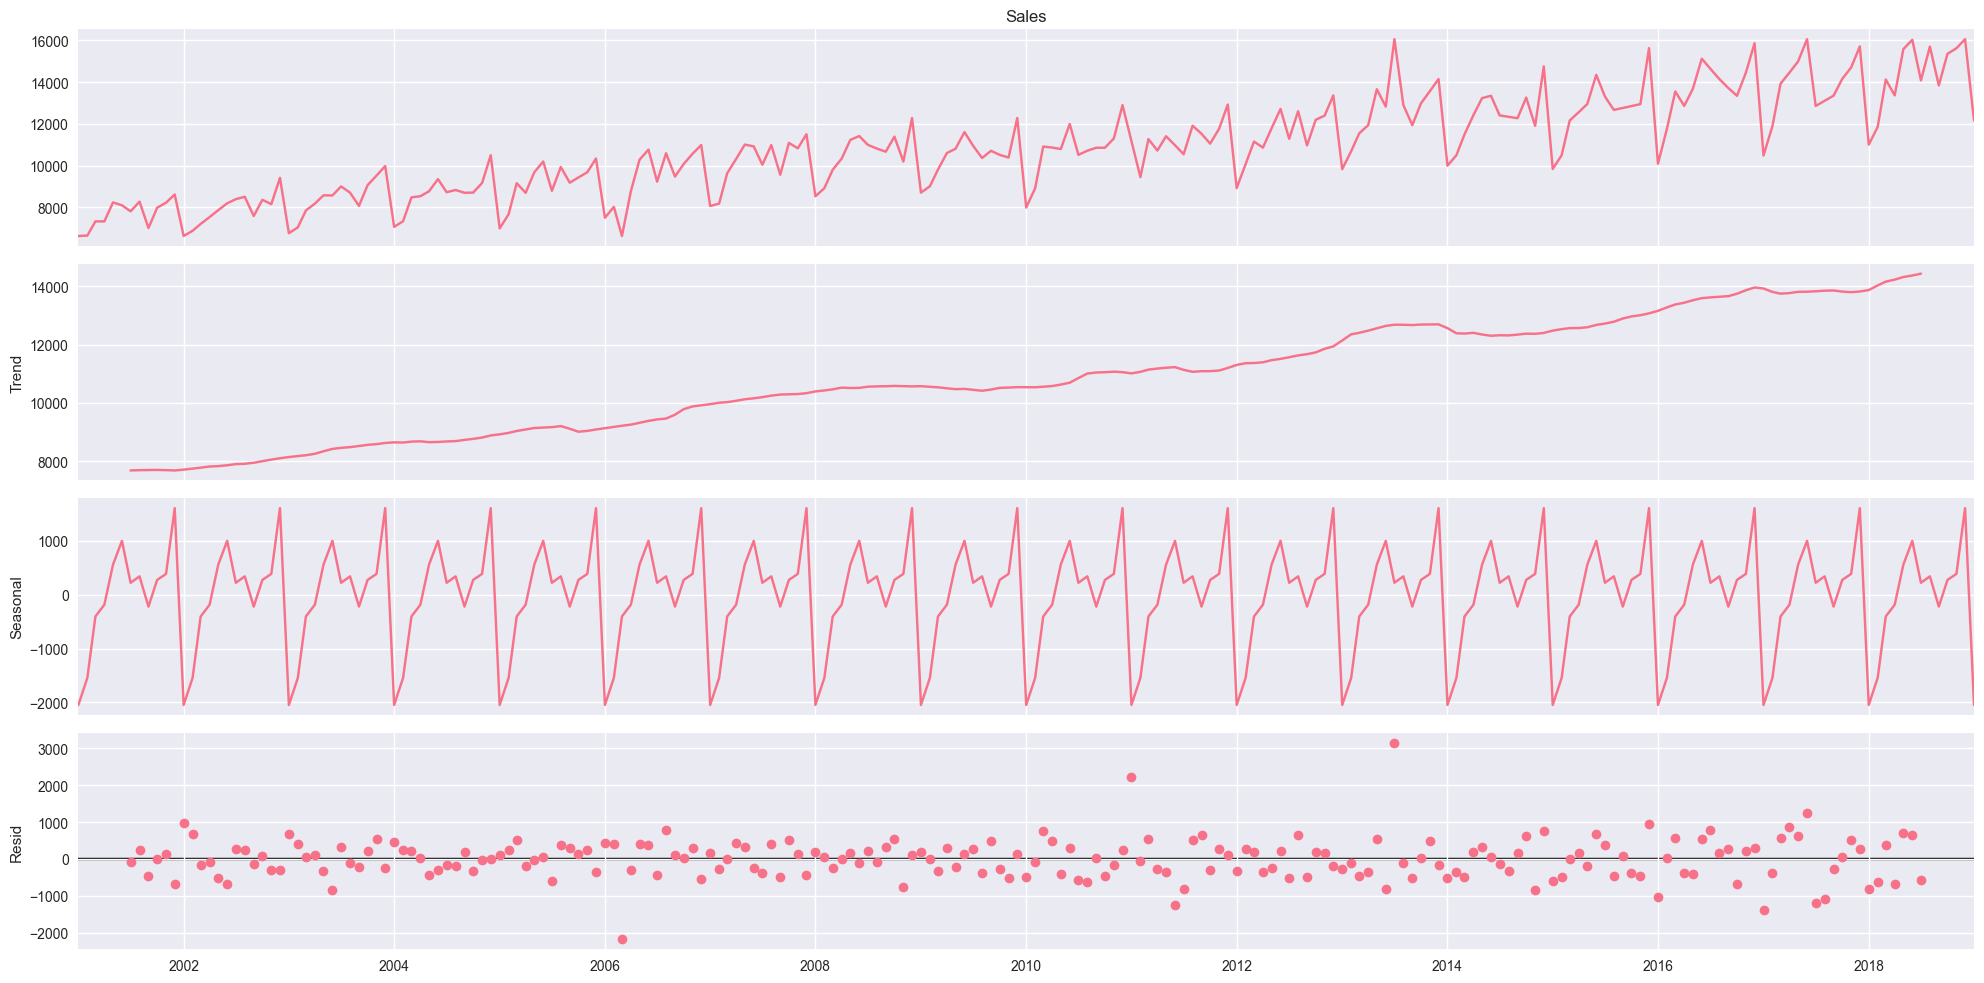

In [82]:
# Perform seasonal decomposition of the Sales time series to extract trend, seasonality, and residuals,
# and plot the decomposed components for visual analysis.
# Decomposition in time series analysis is the process of breaking down a time series into its main components: trend, seasonality, and residual (noise). 
# This helps us understand the underlying patterns in the data.

from statsmodels.tsa.seasonal import seasonal_decompose

# Perform additive decomposition: separates the series into trend, seasonal, and residual components
model = seasonal_decompose(mobile_sales['Sales'], model='additive', period=12)

# Set the figure size for better visualization
plt.rcParams['figure.figsize'] = (20, 10)

# Plot the decomposed components: observed, trend, seasonal, and residual
model.plot();

#### **Decomposition from Scratch**

In [83]:
# This calculates the root mean square (RMS) of the residuals from the decomposition model,
# which measures the average magnitude of the residual (unexplained) component.
(model.resid**2).mean()**0.5

np.float64(546.9498443943686)